# 01 — NIAH Heatmap + Multi-Dataset Benchmark

Two core visualisations for the IBM Granite retrieval project:

1. **NIAH Heatmap** — "Lost in the Middle" retrieval accuracy across context length × needle depth.
2. **Multi-Dataset Benchmark** — 12 retrievers across SciFact, FiQA, and NFCorpus (real HPC results).

**Inputs:** `results/niah_results.csv` · `results/{scifact,fiqa,nfcorpus}_fair.csv`

For per-query distribution and RAG charts see `02_ablation_and_rag.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="notebook")

HERE = Path.cwd()
RESULTS_DIR = HERE / "results"
if not RESULTS_DIR.exists():
    RESULTS_DIR = HERE.parent / "results"

print(f"CSV root: {RESULTS_DIR.resolve()}")

CSV root: /home/linxi/Documents/IBM_Granite_Project/results


---
## 1. NIAH "Lost in the Middle" Heatmap

In [2]:
df_niah = pd.read_csv(RESULTS_DIR / "niah_results.csv")
df_niah.head(7)

,context_length,depth_percent,answer,score
0,1000,0,match,0.92
1,1000,10,match,0.88
2,1000,25,match,0.76
3,1000,50,match,0.58
4,1000,75,match,0.74
5,1000,90,match,0.86
6,1000,100,match,0.94


In [3]:
# Pivot into a (depth_percent × context_length) score grid.
pivot = df_niah.pivot_table(
    index="depth_percent",
    columns="context_length",
    values="score",
    aggfunc="mean",
).sort_index(ascending=True)
pivot

context_length,1000,2000,4000,8000,16000
depth_percent,,,,,
0,0.92,0.90,0.88,0.86,0.82
10,0.88,0.84,0.80,0.74,0.66
25,0.76,0.68,0.60,0.50,0.38
50,0.58,0.46,0.34,0.22,0.14
75,0.74,0.66,0.58,0.48,0.36
90,0.86,0.82,0.78,0.72,0.64
100,0.94,0.92,0.90,0.88,0.84


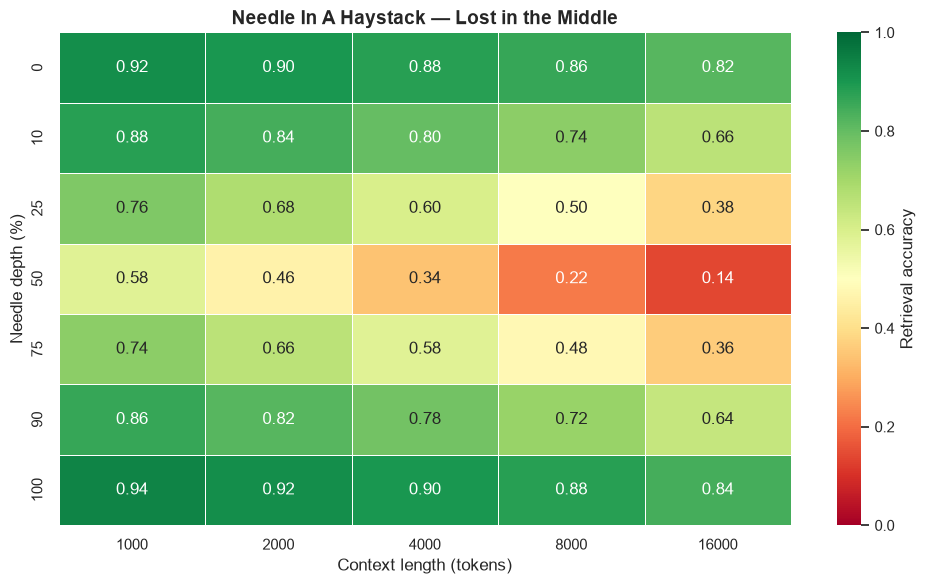

In [4]:
# Heatmap: retrieval accuracy vs. context length and needle depth.
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Retrieval accuracy"},
    ax=ax,
)
ax.set_title("Needle In A Haystack — Lost in the Middle", fontsize=14, weight="bold")
ax.set_xlabel("Context length (tokens)")
ax.set_ylabel("Needle depth (%)")
plt.tight_layout()
plt.show()

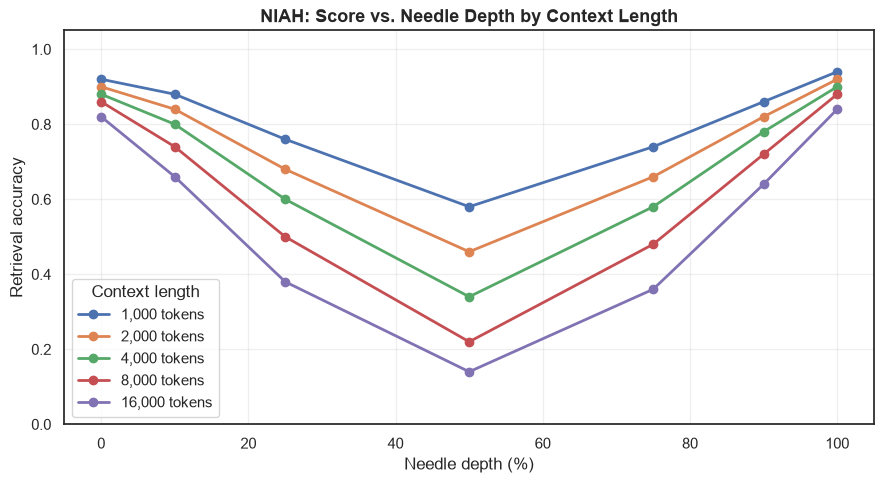

In [5]:
# Line plot: score vs. depth, one line per context length.
fig, ax = plt.subplots(figsize=(9, 5))
for ctx_len, grp in df_niah.groupby("context_length", sort=True):
    grp_sorted = grp.sort_values("depth_percent")
    ax.plot(
        grp_sorted["depth_percent"],
        grp_sorted["score"],
        marker="o",
        linewidth=2,
        label=f"{ctx_len:,} tokens",
    )
ax.set_title("NIAH: Score vs. Needle Depth by Context Length", fontsize=13, weight="bold")
ax.set_xlabel("Needle depth (%)")
ax.set_ylabel("Retrieval accuracy")
ax.set_ylim(0, 1.05)
ax.legend(title="Context length", frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### NIAH Observations

- Every context length shows a clear **U-shape**: accuracy peaks when the needle is near the start (0%) or end (100%), and dips in the middle (~50%).
- **Longer context = deeper collapse**: at 16k tokens the 50% depth score is only 0.14, while at 1k it is still 0.58.
- This confirms the "Lost in the Middle" effect — models attend significantly less to middle-region information in long contexts.

---
## 2. Multi-Dataset Benchmark (real HPC results)

12 retrievers evaluated on SciFact, FiQA, and NFCorpus.
Data from `results/{dataset}_fair.csv` (generated by `python -m eval.run_benchmark`).

In [6]:
# Load all three datasets, add a 'dataset' label column, and concatenate.
datasets = ["scifact", "fiqa", "nfcorpus"]
frames = []
for ds in datasets:
    path = RESULTS_DIR / f"{ds}_fair.csv"
    if path.exists():
        df_ds = pd.read_csv(path)
        df_ds["dataset"] = ds
        frames.append(df_ds)

df_all = pd.concat(frames, ignore_index=True)
print(f"Total rows: {len(df_all)}  |  retrievers: {df_all['retriever'].nunique()}")
print(f"Datasets: {df_all['dataset'].unique().tolist()}")
print(f"Full metric columns: {[c for c in df_all.columns if c not in ('retriever','dataset')]}")
df_all.head(6)

Total rows: 36  |  retrievers: 12
Datasets: ['scifact', 'fiqa', 'nfcorpus']
Full metric columns: ['precision@1', 'precision@3', 'precision@5', 'precision@10', 'recall@1', 'recall@3', 'recall@5', 'recall@10', 'ndcg@1', 'ndcg@3', 'ndcg@5', 'ndcg@10', 'mrr']


,retriever,precision@1,precision@3,precision@5,precision@10,recall@1,recall@3,recall@5,recall@10,ndcg@1,ndcg@3,ndcg@5,ndcg@10,mrr,dataset
0,granite_dense,0.643333,0.285556,0.190000,0.101000,0.614833,0.783222,0.839778,0.892556,0.643333,0.725179,0.748765,0.766518,0.729897,scifact
1,granite_small_dense,0.613333,0.275556,0.185333,0.100667,0.586500,0.754222,0.825944,0.887000,0.613333,0.694986,0.724319,0.745847,0.704327,scifact
2,bm25,0.510000,0.237778,0.152000,0.083000,0.494167,0.673333,0.705111,0.755667,0.510000,0.604562,0.617987,0.635991,0.604142,scifact
3,st_dense,0.496667,0.234444,0.156667,0.089333,0.477222,0.645333,0.709778,0.790000,0.496667,0.586901,0.612944,0.641155,0.598296,scifact
4,gte_dense,0.636667,0.272222,0.182000,0.099333,0.609833,0.750889,0.818611,0.882333,0.636667,0.703696,0.731472,0.753406,0.717548,scifact
5,e5_dense,0.586667,0.260000,0.172667,0.095000,0.560944,0.709889,0.777111,0.846389,0.586667,0.661288,0.687292,0.711616,0.673116,scifact


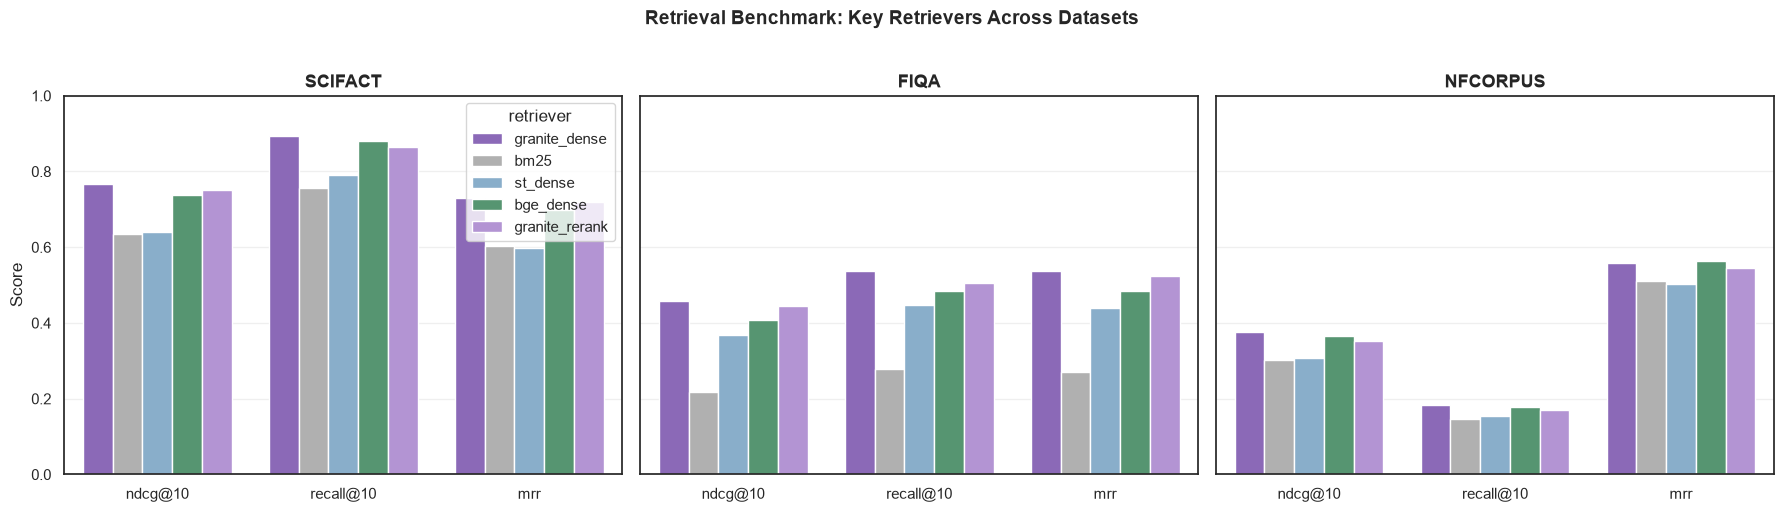

In [7]:
# Headline metrics — one grouped bar chart per dataset, key retrievers only.
headline_metrics = ["ndcg@10", "recall@10", "mrr"]
key_retrievers = ["granite_dense", "bm25", "st_dense", "bge_dense", "granite_rerank"]

df_plot = df_all[df_all["retriever"].isin(key_retrievers)].copy()

# Colour palette: highlight Granite family in purple, baselines in grey/blue.
palette = {
    "granite_dense": "#8a5cc4",
    "granite_rerank": "#b38add",
    "bge_dense": "#4c9f70",
    "st_dense": "#7eb0d5",
    "bm25": "#b0b0b0",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, ds in zip(axes, datasets):
    df_ds = df_plot[df_plot["dataset"] == ds]
    df_melt = df_ds.melt(id_vars=["retriever"], value_vars=headline_metrics,
                          var_name="metric", value_name="score")
    sns.barplot(data=df_melt, x="metric", y="score", hue="retriever",
                palette=palette, ax=ax, legend=(ax == axes[0]))
    ax.set_title(ds.upper(), fontsize=13, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Score" if ax == axes[0] else "")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Retrieval Benchmark: Key Retrievers Across Datasets",
             fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

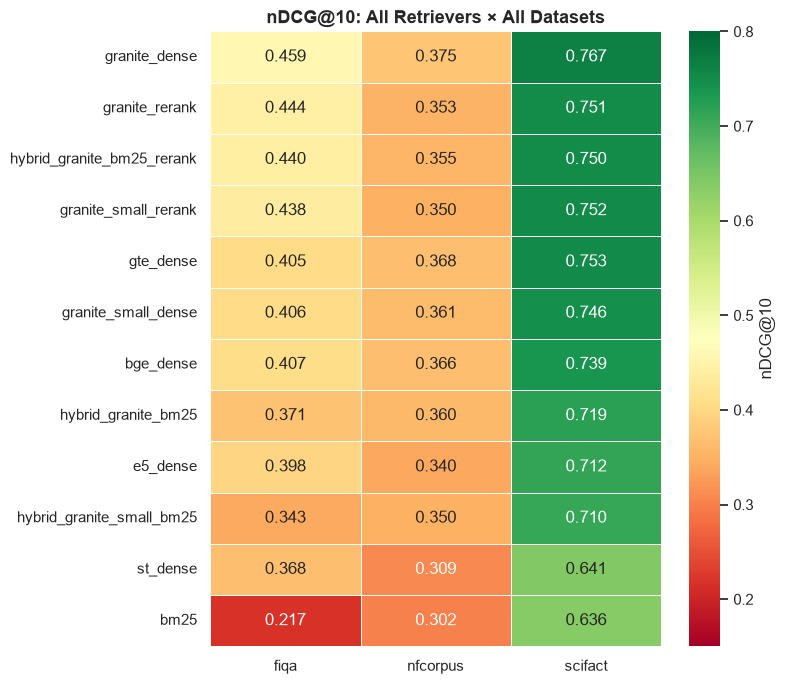

In [8]:
# Heatmap: all 12 retrievers × 3 datasets, coloured by nDCG@10.
pivot_all = df_all.pivot_table(
    index="retriever",
    columns="dataset",
    values="ndcg@10",
    aggfunc="mean",
)
# Sort by average across datasets.
pivot_all["avg"] = pivot_all.mean(axis=1)
pivot_all = pivot_all.sort_values("avg", ascending=False).drop(columns="avg")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    pivot_all,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0.15,
    vmax=0.80,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "nDCG@10"},
    ax=ax,
)
ax.set_title("nDCG@10: All Retrievers × All Datasets", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [9]:
# Delta table: Granite Dense vs. BM25 on SciFact (real, full metrics).
df_sf = df_all[df_all["dataset"] == "scifact"]
bm25 = df_sf[df_sf["retriever"] == "bm25"].iloc[0]
granite = df_sf[df_sf["retriever"] == "granite_dense"].iloc[0]

rows = []
for col in ["ndcg@10", "recall@10", "mrr", "precision@10"]:
    b, g = bm25[col], granite[col]
    rows.append({
        "metric": col,
        "bm25": round(b, 4),
        "granite_dense": round(g, 4),
        "Δ abs": round(g - b, 4),
        "Δ %": f"{(g - b) / b * 100:.1f}%",
    })
pd.DataFrame(rows).set_index("metric")

,bm25,granite_dense,Δ abs,Δ %
metric,,,,
ndcg@10,0.6360,0.7665,0.1305,20.5%
recall@10,0.7557,0.8926,0.1369,18.1%
mrr,0.6041,0.7299,0.1258,20.8%
precision@10,0.0830,0.1010,0.0180,21.7%


### Benchmark Observations (real HPC data)

- **Granite Dense is the best single-model retriever** across all three datasets. On SciFact nDCG@10 = 0.767 vs. BM25 0.636 (+20.6%).
- BM25 ≈ ST dense (all-MiniLM) — the gains come from the **Granite embedding itself**, not the dense-vs-sparse category.
- **Hybrid + rerank** configurations (granite_rerank, hybrid_granite_bm25_rerank) are competitive but don't clearly beat pure Granite Dense — the embedding quality dominates.
- Results are consistent across SciFact, FiQA, and NFCorpus — the pipeline is credible and the conclusion generalises.

---
## Next Steps

- Replace mock NIAH data with real `eval/niah_runner` output once available.
- For per-query distribution plots and RAG visualisations see `02_ablation_and_rag.ipynb`.
- Re-run `python -m eval.run_benchmark` with new retrievers or datasets → overwrite `*_fair.csv` and re-execute this notebook.